In [34]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
contacts = pd.read_csv('../data/task01/contacts.csv')
customers = pd.read_csv('../data/task01/customers.csv')
purchases = pd.read_csv('../data/task01/purchases.csv')


In [3]:
print('Contacts table shape:', contacts.shape)
print('Customers table shape:', customers.shape)
print('Purchases table shape:', purchases.shape)

display(contacts.head())
display(customers.head())
display(purchases.head())


Contacts table shape: (50, 5)
Customers table shape: (50, 10)
Purchases table shape: (100, 6)


,customer_id,first_name,last_name,email,phone
0,1001,Name1,Surname1,user1@example.com,4488800001
1,1002,Name2,Surname2,user2@example.com,4488800002
2,1003,Name3,Surname3,user3@example.com,4488800003
3,1004,Name4,Surname4,user4@example.com,4488800004
4,1005,Name5,Surname5,user5@example.com,4488800005


,customer_id,segment,signup_date,city,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,1001,Group A - Lavish Lifestyles,01/01/2025,Lecester,NaN,NaN,NaN,NaN,NaN,NaN
1,1002,Group D - Digital Natives,04/01/2025,Lecester,NaN,NaN,NaN,NaN,NaN,NaN
2,1003,Group B - Family Focused,07/01/2025,London,NaN,NaN,NaN,NaN,NaN,NaN
3,1004,Group A - Lavish Lifestyles,10/01/2025,Nottingham,NaN,NaN,NaN,NaN,NaN,NaN
4,1005,Group D - Digital Natives,13/01/2025,Manchester,NaN,NaN,NaN,NaN,NaN,NaN


,purchase_id,customer_id,brand,channel,purchase_date,amount
0,2001,1033,BrandQ,Offline,01/02/2025,202.12
1,2002,1002,BrandX,Offline,02/02/2025,108.87
2,2003,1010,BrandQ,Online,03/02/2025,97.17
3,2004,1033,BrandZ,Online,04/02/2025,472.46
4,2005,1032,BrandQ,Online,05/02/2025,371.08


In [4]:
# Removing unnamed columns in the customers table

customers = customers.loc[:, ~customers.columns.str.contains('^Unnamed')]

customers.head()


,customer_id,segment,signup_date,city
0,1001,Group A - Lavish Lifestyles,01/01/2025,Lecester
1,1002,Group D - Digital Natives,04/01/2025,Lecester
2,1003,Group B - Family Focused,07/01/2025,London
3,1004,Group A - Lavish Lifestyles,10/01/2025,Nottingham
4,1005,Group D - Digital Natives,13/01/2025,Manchester


In [25]:
# Tables info

print("Contacts table info:\n")
print(contacts.info())
print("\nCustomers table info:\n")
print(customers.info())

print("\nPurchases table info:\n")
print(purchases.info())

Contacts table info:

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  50 non-null     int64
 1   first_name   50 non-null     str  
 2   last_name    50 non-null     str  
 3   email        50 non-null     str  
 4   phone        50 non-null     int64
dtypes: int64(2), str(3)
memory usage: 2.1 KB
None

Customers table info:

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  50 non-null     int64         
 1   segment      50 non-null     str           
 2   signup_date  49 non-null     datetime64[us]
 3   city         50 non-null     str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 1.7 KB
None

Purchases table info:

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0

In [6]:
# Parsing date fields

customers["signup_date"] = pd.to_datetime(
    customers["signup_date"],
    errors="coerce",
    dayfirst=True
)

purchases["purchase_date"] = pd.to_datetime(
    purchases["purchase_date"],
    errors="coerce",
    dayfirst=True
)

print("\nCustomers table info:")
print(customers.info())

print("\nPurchases table info:")
print(purchases.info())


Customers table info:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  50 non-null     int64         
 1   segment      49 non-null     str           
 2   signup_date  49 non-null     datetime64[us]
 3   city         49 non-null     str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 1.7 KB
None

Purchases table info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   purchase_id    100 non-null    int64         
 1   customer_id    100 non-null    int64         
 2   brand          99 non-null     str           
 3   channel        100 non-null    str           
 4   purchase_date  99 non-null     datetime64[us]
 5   amount         100 non-null    float64       

In [27]:
# Missing values
print(f"Missing values in customers: \n{customers.isna().sum()}")
print()
print(f"Missing values in contacts: \n{contacts.isna().sum()}")
print()
print(f"Missing values in purchases: \n{purchases.isna().sum()}")


Missing values in customers: 
customer_id    0
segment        0
signup_date    1
city           0
dtype: int64

Missing values in contacts: 
customer_id    0
first_name     0
last_name      0
email          0
phone          0
dtype: int64

Missing values in purchases: 
purchase_id      0
customer_id      0
brand            1
channel          0
purchase_date    1
amount           0
dtype: int64


In [8]:
# Filling missing values

customers["segment"] = customers["segment"].fillna("Unknown")
customers["city"] = customers["city"].fillna("Unknown")

In [9]:
# Removing rows

purchases_clean = purchases[
    purchases["brand"].notna()
    & purchases["purchase_date"].notna()
    & purchases["amount"].notna()
    & (purchases["amount"] > 0)
].copy()

print(f"Original purchases rows: {len(purchases)}")
print(f"Clean purchases rows: {len(purchases_clean)}")
print(f"Rows removed: {len(purchases) - len(purchases_clean)}")

print(f"\nMissing values in customers after cleaning:\n{customers.isna().sum()}")

print(f"\nMissing values in purchases_clean:\n{purchases_clean.isna().sum()}")

print(f"\nInvalid purchase amounts remaining:\n{purchases_clean[purchases_clean['amount'] <= 0]}")

Original purchases rows: 100
Clean purchases rows: 96
Rows removed: 4

Missing values in customers after cleaning:
customer_id    0
segment        0
signup_date    1
city           0
dtype: int64

Missing values in purchases_clean:
purchase_id      0
customer_id      0
brand            0
channel          0
purchase_date    0
amount           0
dtype: int64

Invalid purchase amounts remaining:
Empty DataFrame
Columns: [purchase_id, customer_id, brand, channel, purchase_date, amount]
Index: []


In [10]:
# Merge contacts with customers

customer_base = customers.merge(
    contacts,
    on="customer_id",
    how="left"
)

print(f"Customers shape: {customers.shape}")
print(f"Contacts shape: {contacts.shape}")
print(f"Customer base shape: {customer_base.shape}")

print(f"\nMissing values in customer_base:\n{customer_base.isna().sum()}")

print("\nFirst 5 rows:")
print(customer_base.head())

Customers shape: (50, 4)
Contacts shape: (50, 5)
Customer base shape: (50, 8)

Missing values in customer_base:
customer_id    0
segment        0
signup_date    1
city           0
first_name     0
last_name      0
email          0
phone          0
dtype: int64

First 5 rows:
   customer_id                      segment signup_date        city  \
0         1001  Group A - Lavish Lifestyles  2025-01-01    Lecester   
1         1002    Group D - Digital Natives  2025-01-04    Lecester   
2         1003     Group B - Family Focused  2025-01-07      London   
3         1004  Group A - Lavish Lifestyles  2025-01-10  Nottingham   
4         1005    Group D - Digital Natives  2025-01-13  Manchester   

  first_name last_name              email       phone  
0      Name1  Surname1  user1@example.com  4488800001  
1      Name2  Surname2  user2@example.com  4488800002  
2      Name3  Surname3  user3@example.com  4488800003  
3      Name4  Surname4  user4@example.com  4488800004  
4      Name5  Sur

In [11]:
# Merge purchases with customer

purchases_enriched = purchases_clean.merge(
    customer_base,
    on="customer_id",
    how="left"
)

print(f"Purchases clean shape: {purchases_clean.shape}")
print(f"Purchases enriched shape: {purchases_enriched.shape}")

print(f"\nMissing values in purchases_enriched:\n{purchases_enriched.isna().sum()}")

print("\nFirst 5 rows:")
print(purchases_enriched.head())

Purchases clean shape: (96, 6)
Purchases enriched shape: (96, 13)

Missing values in purchases_enriched:
purchase_id      0
customer_id      0
brand            0
channel          0
purchase_date    0
amount           0
segment          0
signup_date      0
city             0
first_name       0
last_name        0
email            0
phone            0
dtype: int64

First 5 rows:
   purchase_id  customer_id   brand  channel purchase_date  amount  \
0         2001         1033  BrandQ  Offline    2025-02-01  202.12   
1         2002         1002  BrandX  Offline    2025-02-02  108.87   
2         2003         1010  BrandQ   Online    2025-02-03   97.17   
3         2004         1033  BrandZ   Online    2025-02-04  472.46   
4         2005         1032  BrandQ   Online    2025-02-05  371.08   

                       segment signup_date        city first_name  last_name  \
0    Group D - Digital Natives  2025-04-07  Nottingham     Name33  Surname33   
1    Group D - Digital Natives  2025-01

In [12]:
# Customer analytic table

customer_analytics = (
    purchases_enriched
    .groupby("customer_id")
    .agg(
        total_spend=("amount", "sum"),
        average_spend=("amount", "mean"),
        purchase_count=("purchase_id", "count"),
        first_purchase=("purchase_date", "min"),
        last_purchase=("purchase_date", "max"),
        brands_bought=("brand", lambda x: ", ".join(sorted(x.unique()))),
        channels_used=("channel", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
)

customer_analytics = customer_analytics.merge(
    customer_base,
    on="customer_id",
    how="right"
)

customer_analytics["total_spend"] = customer_analytics["total_spend"].fillna(0)
customer_analytics["average_spend"] = customer_analytics["average_spend"].fillna(0)
customer_analytics["purchase_count"] = customer_analytics["purchase_count"].fillna(0)

print(f"Customer analytics shape: {customer_analytics.shape}")
print(f"\nMissing values in customer_analytics:\n{customer_analytics.isna().sum()}")
print("\nFirst 5 rows:")
print(customer_analytics.head())

Customer analytics shape: (50, 15)

Missing values in customer_analytics:
customer_id        0
total_spend        0
average_spend      0
purchase_count     0
first_purchase    11
last_purchase     11
brands_bought     11
channels_used     11
segment            0
signup_date        1
city               0
first_name         0
last_name          0
email              0
phone              0
dtype: int64

First 5 rows:
   customer_id  total_spend  average_spend  purchase_count first_purchase  \
0         1001      1703.90     283.983333             6.0     2025-02-12   
1         1002       750.44     187.610000             4.0     2025-02-02   
2         1003       480.98     480.980000             1.0     2025-04-25   
3         1004       562.96     187.653333             3.0     2025-03-17   
4         1005       841.06     280.353333             3.0     2025-02-20   

  last_purchase                   brands_bought    channels_used  \
0    2025-04-21  BrandQ, BrandX, BrandY, BrandZ  Off

In [13]:
# Replacing missing brands_bought and channels_used with None

customer_analytics["brands_bought"] = customer_analytics["brands_bought"].fillna("None")
customer_analytics["channels_used"] = customer_analytics["channels_used"].fillna("None")

print(f"Missing values in customer_analytics after tidy:\n{customer_analytics.isna().sum()}")
print("\nFirst 5 rows:")
print(customer_analytics.head())

Missing values in customer_analytics after tidy:
customer_id        0
total_spend        0
average_spend      0
purchase_count     0
first_purchase    11
last_purchase     11
brands_bought      0
channels_used      0
segment            0
signup_date        1
city               0
first_name         0
last_name          0
email              0
phone              0
dtype: int64

First 5 rows:
   customer_id  total_spend  average_spend  purchase_count first_purchase  \
0         1001      1703.90     283.983333             6.0     2025-02-12   
1         1002       750.44     187.610000             4.0     2025-02-02   
2         1003       480.98     480.980000             1.0     2025-04-25   
3         1004       562.96     187.653333             3.0     2025-03-17   
4         1005       841.06     280.353333             3.0     2025-02-20   

  last_purchase                   brands_bought    channels_used  \
0    2025-04-21  BrandQ, BrandX, BrandY, BrandZ  Offline, Online   
1    2025

In [14]:
# Total and average spend per customer

spend_per_customer = (
    purchases_enriched
    .groupby("customer_id")
    .agg(
        total_spend=("amount", "sum"),
        average_spend=("amount", "mean"),
        purchase_count=("purchase_id", "count")
    )
    .reset_index()
    .sort_values("total_spend", ascending=False)
)

print(f"Spend per customer shape: {spend_per_customer.shape}")
print(spend_per_customer.head(10))

Spend per customer shape: (39, 4)
    customer_id  total_spend  average_spend  purchase_count
0          1001      1703.90     283.983333               6
16         1021      1331.79     443.930000               3
24         1032      1088.14     362.713333               3
27         1036      1063.98     212.796000               5
8          1011       987.85     329.283333               3
32         1042       983.55     245.887500               4
23         1031       923.32     461.660000               2
4          1005       841.06     280.353333               3
37         1049       828.14     276.046667               3
28         1037       820.22     205.055000               4


In [15]:
# Total and average spend per group

spend_per_group = (
    purchases_enriched
    .groupby("segment")
    .agg(
        total_spend=("amount", "sum"),
        average_spend=("amount", "mean"),
        unique_customers=("customer_id", "nunique"),
        purchase_count=("purchase_id", "count")
    )
    .reset_index()
    .sort_values("total_spend", ascending=False)
)

print(f"Spend per group shape: {spend_per_group.shape}")
print(spend_per_group)

Spend per group shape: (6, 5)
                       segment  total_spend  average_spend  unique_customers  \
4    Group D - Digital Natives      6818.13     213.066563                14   
1  Group A - Lavish Lifestyles      6085.32     253.555000                 9   
3   Group C - Budget Conscious      4762.28     238.114000                 7   
2     Group B - Family Focused      4266.99     284.466000                 7   
5                      Unknown      1331.79     443.930000                 1   
0                            3       754.12     377.060000                 1   

   purchase_count  
4              32  
1              24  
3              20  
2              15  
5               3  
0               2  


In [16]:
# Investigate suspicious segment value

print("Unique customer segments:")
print(customers["segment"].unique())

print("\nRows where segment is '3':")
print(customers[customers["segment"].astype(str) == "3"])

print(f"\nSegment counts: {customers["segment"].value_counts(dropna=False)}")


Unique customer segments:
<StringArray>
['Group A - Lavish Lifestyles',   'Group D - Digital Natives',
    'Group B - Family Focused',  'Group C - Budget Conscious',
                     'Unknown',                           '3']
Length: 6, dtype: str

Rows where segment is '3':
    customer_id segment signup_date    city
46         1047       3  2025-05-19  London

Segment counts: segment
Group D - Digital Natives      17
Group A - Lavish Lifestyles    12
Group B - Family Focused       12
Group C - Budget Conscious      7
Unknown                         1
3                               1
Name: count, dtype: int64


In [17]:
# Fixing invalid segment value

customers["segment"] = customers["segment"].replace("3", "Unknown")
customer_base["segment"] = customer_base["segment"].replace("3", "Unknown")
purchases_enriched["segment"] = purchases_enriched["segment"].replace("3", "Unknown")
customer_analytics["segment"] = customer_analytics["segment"].replace("3", "Unknown")

In [18]:
spend_per_group = (
    purchases_enriched
    .groupby("segment")
    .agg(
        total_spend=("amount", "sum"),
        average_spend=("amount", "mean"),
        unique_customers=("customer_id", "nunique"),
        purchase_count=("purchase_id", "count")
    )
    .reset_index()
    .sort_values("total_spend", ascending=False)
)

print(f"Spend per group shape: {spend_per_group.shape}")
print(spend_per_group)

Spend per group shape: (5, 5)
                       segment  total_spend  average_spend  unique_customers  \
3    Group D - Digital Natives      6818.13     213.066563                14   
0  Group A - Lavish Lifestyles      6085.32     253.555000                 9   
2   Group C - Budget Conscious      4762.28     238.114000                 7   
1     Group B - Family Focused      4266.99     284.466000                 7   
4                      Unknown      2085.91     417.182000                 2   

   purchase_count  
3              32  
0              24  
2              20  
1              15  
4               5  


In [19]:
# Total spend per brand and channel

spend_per_brand_channel = (
    purchases_enriched
    .groupby(["brand", "channel"])
    .agg(
        total_spend=("amount", "sum"),
        average_spend=("amount", "mean"),
        unique_customers=("customer_id", "nunique"),
        purchase_count=("purchase_id", "count")
    )
    .reset_index()
    .sort_values(["brand", "channel"])
)

print(f"Spend per brand and channel shape: {spend_per_brand_channel.shape}")
print(spend_per_brand_channel)

Spend per brand and channel shape: (8, 6)
    brand  channel  total_spend  average_spend  unique_customers  \
0  BrandQ  Offline      2594.54     216.211667                12   
1  BrandQ   Online      3272.39     297.490000                10   
2  BrandX  Offline      4848.30     255.173684                17   
3  BrandX   Online      1893.42     172.129091                10   
4  BrandY  Offline      3855.64     296.587692                12   
5  BrandY   Online      2954.08     295.408000                 9   
6  BrandZ  Offline      2503.53     250.353000                 9   
7  BrandZ   Online      2096.73     209.673000                 8   

   purchase_count  
0              12  
1              11  
2              19  
3              11  
4              13  
5              10  
6              10  
7              10  


In [20]:
# Online vs offline share per brand

brand_totals = (
    spend_per_brand_channel
    .groupby("brand")["total_spend"]
    .sum()
    .reset_index()
    .rename(columns={"total_spend": "brand_total_spend"})
)

brand_channel_share = spend_per_brand_channel.merge(
    brand_totals,
    on="brand",
    how="left"
)

brand_channel_share["channel_share"] = (
    brand_channel_share["total_spend"] / brand_channel_share["brand_total_spend"]
)

brand_channel_share["channel_share_pct"] = (
    brand_channel_share["channel_share"] * 100
).round(2)

print(f"Brand channel share shape: {brand_channel_share.shape}")
print(brand_channel_share)

Brand channel share shape: (8, 9)
    brand  channel  total_spend  average_spend  unique_customers  \
0  BrandQ  Offline      2594.54     216.211667                12   
1  BrandQ   Online      3272.39     297.490000                10   
2  BrandX  Offline      4848.30     255.173684                17   
3  BrandX   Online      1893.42     172.129091                10   
4  BrandY  Offline      3855.64     296.587692                12   
5  BrandY   Online      2954.08     295.408000                 9   
6  BrandZ  Offline      2503.53     250.353000                 9   
7  BrandZ   Online      2096.73     209.673000                 8   

   purchase_count  brand_total_spend  channel_share  channel_share_pct  
0              12            5866.93       0.442231              44.22  
1              11            5866.93       0.557769              55.78  
2              19            6741.72       0.719149              71.91  
3              11            6741.72       0.280851          

In [21]:
online_offline_share = (
    brand_channel_share
    .pivot_table(
        index="brand",
        columns="channel",
        values="channel_share_pct",
        fill_value=0
    )
    .reset_index()
)

print("\nOnline vs Offline Share by Brand:")
print(online_offline_share)


Online vs Offline Share by Brand:
channel   brand  Offline  Online
0        BrandQ    44.22   55.78
1        BrandX    71.91   28.09
2        BrandY    56.62   43.38
3        BrandZ    54.42   45.58


In [22]:
# Best city per brand

brand_city_spend = (
    purchases_enriched
    .groupby(["brand", "city"])
    .agg(
        total_spend=("amount", "sum"),
        average_spend=("amount", "mean"),
        unique_customers=("customer_id", "nunique"),
        purchase_count=("purchase_id", "count")
    )
    .reset_index()
    .sort_values(["brand", "total_spend"], ascending=[True, False])
)

print(f"Brand city spend shape: {brand_city_spend.shape}")
print(brand_city_spend)

Brand city spend shape: (23, 6)
     brand        city  total_spend  average_spend  unique_customers  \
1   BrandQ    Lecester      2717.67     301.963333                 6   
2   BrandQ      London      1562.46     312.492000                 4   
3   BrandQ  Manchester       686.20     343.100000                 2   
0   BrandQ    Aberdeen       501.92     167.306667                 3   
4   BrandQ  Nottingham       398.68      99.670000                 4   
5   BrandX    Aberdeen      1615.60     230.800000                 4   
8   BrandX  Manchester      1551.37     387.842500                 3   
6   BrandX    Lecester      1215.08     151.885000                 7   
9   BrandX  Nottingham      1109.52     184.920000                 3   
7   BrandX      London      1073.27     268.317500                 4   
10  BrandX     Unknown       176.88     176.880000                 1   
12  BrandY    Lecester      3062.46     306.246000                 9   
15  BrandY  Nottingham      1133

In [23]:
# Best cities per brand

best_city_per_brand = (
    brand_city_spend
    .sort_values(["brand", "total_spend"], ascending=[True, False])
    .groupby("brand")
    .head(1)
    .reset_index(drop=True)
)

print("\nBest city per brand:")
print(best_city_per_brand)


Best city per brand:
    brand      city  total_spend  average_spend  unique_customers  \
0  BrandQ  Lecester      2717.67     301.963333                 6   
1  BrandX  Aberdeen      1615.60     230.800000                 4   
2  BrandY  Lecester      3062.46     306.246000                 9   
3  BrandZ  Lecester      1842.44     230.305000                 5   

   purchase_count  
0               9  
1               7  
2              10  
3               8  


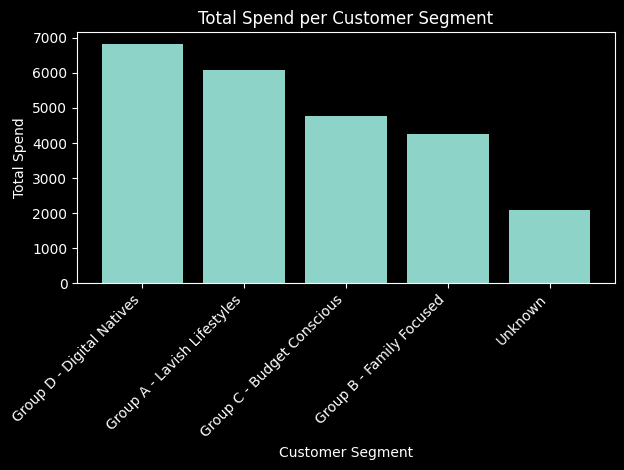

In [24]:
# Spend per group segment plot

spend_per_group_plot = spend_per_group.sort_values("total_spend", ascending=False)

plt.bar(
    spend_per_group_plot["segment"],
    spend_per_group_plot["total_spend"]
)

plt.title("Total Spend per Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Spend")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [28]:
# Brand info with customer information

customer_analytics

,customer_id,total_spend,average_spend,purchase_count,first_purchase,last_purchase,brands_bought,channels_used,segment,signup_date,city,first_name,last_name,email,phone
0,1001,1703.90,283.983333,6.0,2025-02-12,2025-04-21,"BrandQ, BrandX, BrandY, BrandZ","Offline, Online",Group A - Lavish Lifestyles,2025-01-01,Lecester,Name1,Surname1,user1@example.com,4488800001
1,1002,750.44,187.610000,4.0,2025-02-02,2025-05-08,"BrandX, BrandY, BrandZ","Offline, Online",Group D - Digital Natives,2025-01-04,Lecester,Name2,Surname2,user2@example.com,4488800002
2,1003,480.98,480.980000,1.0,2025-04-25,2025-04-25,BrandX,Offline,Group B - Family Focused,2025-01-07,London,Name3,Surname3,user3@example.com,4488800003
3,1004,562.96,187.653333,3.0,2025-03-17,2025-04-29,"BrandQ, BrandY, BrandZ",Online,Group A - Lavish Lifestyles,2025-01-10,Nottingham,Name4,Surname4,user4@example.com,4488800004
4,1005,841.06,280.353333,3.0,2025-02-20,2025-03-15,"BrandX, BrandZ",Offline,Group D - Digital Natives,2025-01-13,Manchester,Name5,Surname5,user5@example.com,4488800005
5,1006,469.51,156.503333,3.0,2025-02-15,2025-04-05,"BrandX, BrandY","Offline, Online",Group D - Digital Natives,2025-01-16,Lecester,Name6,Surname6,user6@example.com,4488800006
6,1007,110.59,110.590000,1.0,2025-03-14,2025-03-14,BrandX,Offline,Group D - Digital Natives,2025-01-19,London,Name7,Surname7,user7@example.com,4488800007
7,1008,0.00,0.000000,0.0,NaT,NaT,None,None,Group D - Digital Natives,2025-01-22,Aberdeen,Name8,Surname8,user8@example.com,4488800008
8,1009,0.00,0.000000,0.0,NaT,NaT,None,None,Group B - Family Focused,NaT,Manchester,Name9,Surname9,user9@example.com,4488800009
9,1010,133.83,66.915000,2.0,2025-02-03,2025-04-20,"BrandQ, BrandX","Offline, Online",Group D - Digital Natives,2025-01-28,Aberdeen,Name10,Surname10,user10@example.com,4488800010


In [35]:
# Existing/Potential brand customers db creation
brand_customer_db_list = []

for brand in brand_totals.brand:
    target_segments = purchases_enriched.loc[
        purchases_enriched["brand"] == brand,
        "segment"
    ].unique()

    existing_customers_id = purchases_enriched.loc[
        purchases_enriched["brand"] == brand,
        'customer_id'
    ]

    brand_customers = customer_base.loc[
        customer_base['segment'].isin(target_segments),
    ].copy()

    brand_customers['brand'] = brand

    brand_customers['customer_status'] = np.where(
        brand_customers['customer_id'].isin(existing_customers_id),
        'existing',
        'potential'
    )

    brand_customer_db_list.append(brand_customers)

brand_customer_db = pd.concat(brand_customer_db_list, ignore_index=True)

print(brand_customer_db.head())
print(brand_customer_db.shape)

   customer_id                      segment signup_date        city  \
0         1001  Group A - Lavish Lifestyles  2025-01-01    Lecester   
1         1002    Group D - Digital Natives  2025-01-04    Lecester   
2         1003     Group B - Family Focused  2025-01-07      London   
3         1004  Group A - Lavish Lifestyles  2025-01-10  Nottingham   
4         1005    Group D - Digital Natives  2025-01-13  Manchester   

  first_name last_name              email       phone   brand customer_status  
0      Name1  Surname1  user1@example.com  4488800001  BrandQ        existing  
1      Name2  Surname2  user2@example.com  4488800002  BrandQ       potential  
2      Name3  Surname3  user3@example.com  4488800003  BrandQ       potential  
3      Name4  Surname4  user4@example.com  4488800004  BrandQ        existing  
4      Name5  Surname5  user5@example.com  4488800005  BrandQ       potential  
(198, 10)


In [36]:
# Brand-Customer DB final

brand_customer_db['full_name'] = (
    brand_customer_db.first_name + " " + brand_customer_db.last_name
)

brand_customer_db_final = brand_customer_db[
    ['brand',
    'customer_status',
    'customer_id',
    'full_name',
    'email',
    'phone',
    'segment',
    'city'
     ]
]. copy()

print(brand_customer_db_final.head())

    brand customer_status  customer_id       full_name              email  \
0  BrandQ        existing         1001  Name1 Surname1  user1@example.com   
1  BrandQ       potential         1002  Name2 Surname2  user2@example.com   
2  BrandQ       potential         1003  Name3 Surname3  user3@example.com   
3  BrandQ        existing         1004  Name4 Surname4  user4@example.com   
4  BrandQ       potential         1005  Name5 Surname5  user5@example.com   

        phone                      segment        city  
0  4488800001  Group A - Lavish Lifestyles    Lecester  
1  4488800002    Group D - Digital Natives    Lecester  
2  4488800003     Group B - Family Focused      London  
3  4488800004  Group A - Lavish Lifestyles  Nottingham  
4  4488800005    Group D - Digital Natives  Manchester  


In [37]:
# Brand exist vs potential customers

brand_customers_status_summary = (
    brand_customer_db_final
    .groupby(["brand", "customer_status"])
    .agg(customets=("customer_id", "nunique"))
    .reset_index()
)

print(brand_customers_status_summary)

    brand customer_status  customets
0  BrandQ        existing         19
1  BrandQ       potential         31
2  BrandX        existing         22
3  BrandX       potential         28
4  BrandY        existing         20
5  BrandY       potential         30
6  BrandZ        existing         16
7  BrandZ       potential         32


In [42]:
# Export all brand data to csv
brand_customer_db_final.to_csv(
    '../outputs/brand_customer_db_final.csv',
    index=False
)

In [44]:
# Export csv per brand

for brand in brand_customer_db_final.brand.unique():
    brand_db = brand_customer_db_final[
        brand_customer_db_final.brand == brand
    ]

    brand_db.to_csv(
        f'../outputs/{brand}_db.csv',
    )

    print(f"{brand}_db.csv Created!")

BrandQ_db.csv Created!
BrandX_db.csv Created!
BrandY_db.csv Created!
BrandZ_db.csv Created!


In [48]:
# Spend for Brand

purchases_enriched


,purchase_id,customer_id,brand,channel,purchase_date,amount,segment,signup_date,city,first_name,last_name,email,phone
0,2001,1033,BrandQ,Offline,2025-02-01,202.12,Group D - Digital Natives,2025-04-07,Nottingham,Name33,Surname33,user33@example.com,4488800033
1,2002,1002,BrandX,Offline,2025-02-02,108.87,Group D - Digital Natives,2025-01-04,Lecester,Name2,Surname2,user2@example.com,4488800002
2,2003,1010,BrandQ,Online,2025-02-03,97.17,Group D - Digital Natives,2025-01-28,Aberdeen,Name10,Surname10,user10@example.com,4488800010
3,2004,1033,BrandZ,Online,2025-02-04,472.46,Group D - Digital Natives,2025-04-07,Nottingham,Name33,Surname33,user33@example.com,4488800033
4,2005,1032,BrandQ,Online,2025-02-05,371.08,Group A - Lavish Lifestyles,2025-04-04,Lecester,Name32,Surname32,user32@example.com,4488800032
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,2096,1042,BrandX,Offline,2025-05-07,78.33,Group D - Digital Natives,2025-05-04,Nottingham,Name42,Surname42,user42@example.com,4488800042
92,2097,1002,BrandY,Offline,2025-05-08,491.01,Group D - Digital Natives,2025-01-04,Lecester,Name2,Surname2,user2@example.com,4488800002
93,2098,1037,BrandX,Offline,2025-05-09,241.79,Group C - Budget Conscious,2025-04-19,Aberdeen,Name37,Surname37,user37@example.com,4488800037
94,2099,1011,BrandQ,Online,2025-05-10,251.21,Group B - Family Focused,2025-01-31,Lecester,Name11,Surname11,user11@example.com,4488800011


In [50]:
purchases_enriched['month'] = (
    purchases_enriched['purchase_date'].dt.to_period('M').dt.to_timestamp()
)

purchases_enriched.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   purchase_id    96 non-null     int64         
 1   customer_id    96 non-null     int64         
 2   brand          96 non-null     str           
 3   channel        96 non-null     str           
 4   purchase_date  96 non-null     datetime64[us]
 5   amount         96 non-null     float64       
 6   segment        96 non-null     str           
 7   signup_date    96 non-null     datetime64[us]
 8   city           96 non-null     str           
 9   first_name     96 non-null     str           
 10  last_name      96 non-null     str           
 11  email          96 non-null     str           
 12  phone          96 non-null     int64         
 13  month          96 non-null     datetime64[us]
dtypes: datetime64[us](3), float64(1), int64(3), str(7)
memory usage: 10.6 KB


In [57]:
purchases_enriched['month_number'] = purchases_enriched.purchase_date.dt.month
purchases_enriched['month'] = purchases_enriched.purchase_date.dt.month_name()

brand_monthly_spend = (
    purchases_enriched
    .groupby(["brand", "month", 'month_number'])
    .agg(total_spend=("amount", "sum"))
    .reset_index()
    .sort_values(["month_number", "brand"])
)

print(brand_monthly_spend)

     brand     month  month_number  total_spend
1   BrandQ  February             2      1477.89
5   BrandX  February             2      1548.41
9   BrandY  February             2       888.21
13  BrandZ  February             2      1767.71
2   BrandQ     March             3      1161.09
6   BrandX     March             3      2580.57
10  BrandY     March             3      1907.60
14  BrandZ     March             3       957.81
0   BrandQ     April             4      2665.89
4   BrandX     April             4      2115.74
8   BrandY     April             4      2509.85
12  BrandZ     April             4      1541.65
3   BrandQ       May             5       562.06
7   BrandX       May             5       497.00
11  BrandY       May             5      1504.06
15  BrandZ       May             5       333.09


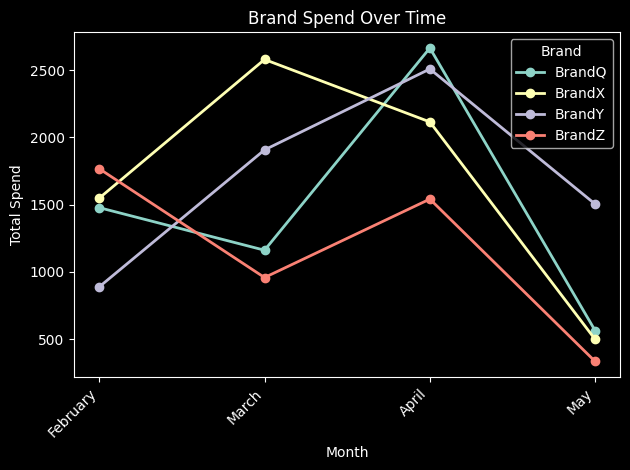

In [63]:
# Brand Spend over time plot
for brand in brand_monthly_spend["brand"].unique():
    brand_data = brand_monthly_spend[
        brand_monthly_spend["brand"] == brand
    ].sort_values("month_number")

    plt.plot(
        brand_data["month"],
        brand_data["total_spend"],
        marker="o",
        linewidth=2,
        label=brand
    )

plt.title("Brand Spend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Spend")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Brand")
plt.tight_layout()
plt.show()